# Project 2 — Multi-Agent Reinforcement Learning on a Stochastic Game

Simplified football stochastic game from M. L. Littman (1994), *Markov games as a framework for multi-agent reinforcement learning*, ICML'94.

Grid is 4 rows × 5 columns, all playable. The two goal boxes sit *outside* the grid, one to the West of column 0 (`B`'s Goal, where `A` scores) and one to the East of column 4 (`A`'s Goal, where `B` scores), and are only reachable from rows 1 and 2 (the two middle rows of the four). A player scores by carrying the ball and attempting to move off the grid through the correct edge from one of those rows; the same attempt from row 0 or row 3, or without the ball, is simply a blocked move. Two players choose one of `{N, S, E, W, stand}` each turn; both moves are then resolved in a uniformly random order. A move into the square currently occupied by the other player is blocked and, if the mover currently has the ball, possession is transferred to the occupying player instead.

In [1]:
import random
import time
import pandas as pd
import matplotlib.pyplot as plt

ROWS, COLS = 4, 5
ACTIONS = ["N", "S", "E", "W", "stand"]
DELTAS = {"N": (-1, 0), "S": (1, 0), "E": (0, 1), "W": (0, -1), "stand": (0, 0)}
NUM_ACTIONS = len(ACTIONS)
NUM_CELLS = ROWS * COLS
NUM_STATES = NUM_CELLS * NUM_CELLS * 2

A_START = (1, 3)
B_START = (2, 1)

In [ ]:
def cell_id(pos):
    r, c = pos
    return r * COLS + c


def encode_state(pos_a, pos_b, ball_owner):
    return (cell_id(pos_a) * NUM_CELLS + cell_id(pos_b)) * 2 + ball_owner


def in_bounds(pos):
    r, c = pos
    return 0 <= r < ROWS and 0 <= c < COLS


GOAL_ROWS = (1, 2)  # only these two (of four) rows lead to a goal box


class FootballEnv:
    def __init__(self, rng):
        self.rng = rng
        self.reset()

    def reset(self):
        self.pos = {"A": A_START, "B": B_START}
        self.ball_owner = self.rng.choice(["A", "B"])
        return self.state()

    def state(self):
        return encode_state(self.pos["A"], self.pos["B"], 0 if self.ball_owner == "A" else 1)

    def step(self, action_a, action_b):
        actions = {"A": action_a, "B": action_b}
        order = ["A", "B"] if self.rng.random() < 0.5 else ["B", "A"]
        scorer = None
        for player in order:
            other = "B" if player == "A" else "A"
            dr, dc = DELTAS[actions[player]]
            r, c = self.pos[player]
            target = (r + dr, c + dc)

            if dc != 0 and not (0 <= target[1] < COLS):
                # Attempting to leave the field to the West (from column 0,
                # into B's Goal) or East (from column COLS-1, into A's
                # Goal). The goal boxes sit outside the grid and are only
                # reachable from the two middle rows; scoring also requires
                # actually carrying the ball and heading toward the
                # opponent's own goal (A exits West, B exits East).
                # Anything else at that edge is just a blocked move.
                exiting_west = target[1] < 0
                in_scoring_row = r in GOAL_ROWS
                has_ball = self.ball_owner == player
                correct_direction = (exiting_west and player == "A") or (not exiting_west and player == "B")
                if in_scoring_row and has_ball and correct_direction:
                    scorer = player
                    break
                continue

            if not in_bounds(target):
                continue
            if target == self.pos[other]:
                if self.ball_owner == player:
                    self.ball_owner = other
                continue
            self.pos[player] = target

        reward = {"A": 0.0, "B": 0.0}
        done = False
        if scorer is not None:
            loser = "B" if scorer == "A" else "A"
            reward[scorer] = 1.0
            reward[loser] = -1.0
            done = True
            self.reset()
        return self.state(), reward, done

In [3]:
class JALAgent:
    """Joint-action learner"""

    def __init__(self, epsilon, rng):
        self.epsilon = epsilon
        self.rng = rng
        self.Q = [[[0.0] * NUM_ACTIONS for _ in range(NUM_ACTIONS)] for _ in range(NUM_STATES)]
        self.counts = [[0] * NUM_ACTIONS for _ in range(NUM_STATES)]

    def belief(self, s):
        c = self.counts[s]
        total = sum(c)
        if total == 0:
            return [1.0 / NUM_ACTIONS] * NUM_ACTIONS
        return [x / total for x in c]

    def ev(self, s):
        b = self.belief(s)
        q = self.Q[s]
        return [sum(q[a][ap] * b[ap] for ap in range(NUM_ACTIONS)) for a in range(NUM_ACTIONS)]

    def act(self, s, greedy=False):
        if not greedy and self.rng.random() < self.epsilon:
            return self.rng.randrange(NUM_ACTIONS)
        values = self.ev(s)
        best_value = max(values)
        best = [a for a, v in enumerate(values) if v == best_value]
        return self.rng.choice(best)

    def observe(self, s, a_self, a_opp, reward, s_next, alpha, gamma):
        target = reward + gamma * max(self.ev(s_next))
        q = self.Q[s][a_self]
        q[a_opp] += alpha * (target - q[a_opp])
        self.counts[s][a_opp] += 1


class RandomAgent:
    def __init__(self, rng):
        self.rng = rng

    def act(self, s, greedy=False):
        return self.rng.randrange(NUM_ACTIONS)

    def observe(self, *args, **kwargs):
        pass

In [4]:
def alpha_decay_factor(alpha0, alpha_end, total_steps):
    return (alpha_end / alpha0) ** (1.0 / total_steps)


def train(agent_a, agent_b, steps, gamma, rng, alpha0=1.0, alpha_end=0.01):
    env = FootballEnv(rng)
    alpha = alpha0
    decay = alpha_decay_factor(alpha0, alpha_end, steps)
    s = env.state()
    for _ in range(steps):
        a = agent_a.act(s)
        b = agent_b.act(s)
        s_next, reward, _ = env.step(ACTIONS[a], ACTIONS[b])
        agent_a.observe(s, a, b, reward["A"], s_next, alpha, gamma)
        agent_b.observe(s, b, a, reward["B"], s_next, alpha, gamma)
        s = s_next
        alpha *= decay


def evaluate(agent_a, agent_b, steps, gamma, rng):
    env = FootballEnv(rng)
    s = env.state()
    games = 0
    wins_a = 0
    wins_b = 0
    episode_lengths = []  # steps-to-goal for decisive games only
    steps_since_reset = 0
    for _ in range(steps):
        if rng.random() < (1.0 - gamma):
            games += 1
            s = env.reset()
            steps_since_reset = 0
            continue
        a = agent_a.act(s, greedy=True)
        b = agent_b.act(s, greedy=True)
        s_next, reward, done = env.step(ACTIONS[a], ACTIONS[b])
        steps_since_reset += 1
        if done:
            games += 1
            episode_lengths.append(steps_since_reset)
            steps_since_reset = 0
            if reward["A"] > 0:
                wins_a += 1
            elif reward["B"] > 0:
                wins_b += 1
        s = s_next
    return {
        "games": games,
        "win_rate_a": wins_a / games if games else 0.0,
        "win_rate_b": wins_b / games if games else 0.0,
        "avg_episode_length": sum(episode_lengths) / len(episode_lengths) if episode_lengths else 0.0,
    }

In [5]:
TRAIN_STEPS = 1_000_000
TEST_STEPS = 100_000
EPSILON = 0.2
GAMMA = 0.9
SEED = 27

rng = random.Random(SEED)
start = time.perf_counter()

a_rand = JALAgent(EPSILON, rng)
train(a_rand, RandomAgent(rng), TRAIN_STEPS, GAMMA, rng)

b_rand = JALAgent(EPSILON, rng)
train(RandomAgent(rng), b_rand, TRAIN_STEPS, GAMMA, rng)

a_self = JALAgent(EPSILON, rng)
b_self = JALAgent(EPSILON, rng)
train(a_self, b_self, TRAIN_STEPS, GAMMA, rng)

print(f"Training (3 x {TRAIN_STEPS:,} steps) finished in {time.perf_counter()-start:.1f}s")

results = {
    "A (random-trained) vs random": evaluate(a_rand, RandomAgent(rng), TEST_STEPS, GAMMA, rng),
    "A (self-play-trained) vs random": evaluate(a_self, RandomAgent(rng), TEST_STEPS, GAMMA, rng),
    "random-trained pair vs each other": evaluate(a_rand, b_rand, TEST_STEPS, GAMMA, rng),
    "self-play pair vs each other": evaluate(a_self, b_self, TEST_STEPS, GAMMA, rng),
}

results_df = pd.DataFrame(results).T
results_df["draw %"] = 100 - 100 * (results_df.win_rate_a + results_df.win_rate_b)
results_df["decided %"] = 100 - results_df["draw %"]

results_df["A decisive win %"] = 100 * results_df.win_rate_a / (results_df.win_rate_a + results_df.win_rate_b)
results_df["B decisive win %"] = 100 * results_df.win_rate_b / (results_df.win_rate_a + results_df.win_rate_b)

results_df[["games", "decided %", "A decisive win %", "B decisive win %", "avg_episode_length"]]

Training (3 x 1,000,000 steps) finished in 37.3s


,games,decided %,A decisive win %,B decisive win %,avg_episode_length
A (random-trained) vs random,19975.0,50.543179,98.801506,1.198494,5.784865
A (self-play-trained) vs random,17530.0,43.839133,99.856864,0.143136,6.338842
random-trained pair vs each other,29112.0,65.333883,49.889590,50.110410,4.000000
self-play pair vs each other,18617.0,45.990224,49.661294,50.338706,6.843144


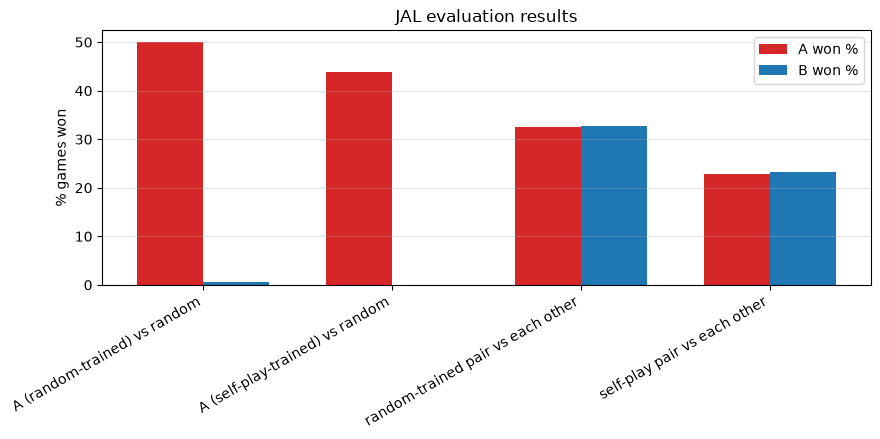

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
labels = list(results.keys())
a_pct = [100 * results[k]["win_rate_a"] for k in labels]
b_pct = [100 * results[k]["win_rate_b"] for k in labels]
x = range(len(labels))
width = 0.35
ax.bar([i - width / 2 for i in x], a_pct, width, label="A won %", color="tab:red")
ax.bar([i + width / 2 for i in x], b_pct, width, label="B won %", color="tab:blue")
ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylabel("% games won")
ax.set_title("JAL evaluation results")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Visualizing a game

In [ ]:
def draw_football_frame(ax, pos_a, pos_b, ball_owner, title=""):
    goal_top = min(GOAL_ROWS)
    goal_height = max(GOAL_ROWS) - min(GOAL_ROWS) + 1

    ax.set_xlim(-1.3, COLS + 1.3)
    ax.set_ylim(-0.3, ROWS + 0.3)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    for r in range(ROWS):
        for c in range(COLS):
            ax.add_patch(plt.Rectangle((c, r), 1, 1, fill=False, edgecolor="black", linewidth=0.8))

    ax.add_patch(plt.Rectangle((-1, goal_top), 1, goal_height, fill=False, edgecolor="black", linewidth=0.8))
    ax.text(-0.5, goal_top + goal_height / 2, "B's\nGoal", ha="center", va="center", fontsize=7)
    ax.add_patch(plt.Rectangle((COLS, goal_top), 1, goal_height, fill=False, edgecolor="black", linewidth=0.8))
    ax.text(COLS + 0.5, goal_top + goal_height / 2, "A's\nGoal", ha="center", va="center", fontsize=7)

    for label, pos, color in [("A", pos_a, "tab:red"), ("B", pos_b, "tab:blue")]:
        pr, pc = pos
        ax.scatter([pc + 0.5], [pr + 0.5], s=280, color=color, zorder=3)
        ax.text(pc + 0.5, pr + 0.5, label, ha="center", va="center", color="white",
                 fontsize=9, fontweight="bold", zorder=4)

    owner_pos = pos_a if ball_owner == "A" else pos_b
    orow, ocol = owner_pos
    ax.add_patch(plt.Circle((ocol + 0.5, orow + 0.5), 0.42, fill=False, edgecolor="black", linewidth=2, zorder=5))

    ax.set_title(title, fontsize=8)


def simulate_game_trace(agent_a, agent_b, rng, max_steps=15):
    """Play one greedy game to completion (or up to max_steps) and record a
    frame after every step. The scoring player's frame reuses their
    pre-move position (the goal box is outside the grid, so there is no
    on-grid position to show 'inside' the goal)."""
    env = FootballEnv(rng)
    frames = [{
        "pos_a": env.pos["A"], "pos_b": env.pos["B"], "ball_owner": env.ball_owner,
        "title": "start",
    }]
    for step in range(1, max_steps + 1):
        s = env.state()
        a = agent_a.act(s, greedy=True)
        b = agent_b.act(s, greedy=True)
        pre_pos_a, pre_pos_b, pre_owner = env.pos["A"], env.pos["B"], env.ball_owner
        _, reward, done = env.step(ACTIONS[a], ACTIONS[b])
        if done:
            scorer = "A" if reward["A"] > 0 else "B"
            frames.append({
                "pos_a": pre_pos_a, "pos_b": pre_pos_b, "ball_owner": pre_owner,
                "title": f"step {step}\nGOAL: {scorer}!",
            })
            break
        frames.append({
            "pos_a": env.pos["A"], "pos_b": env.pos["B"], "ball_owner": env.ball_owner,
            "title": f"step {step}",
        })
    return frames


def plot_game_trace(frames, suptitle, max_per_row=6):
    n = len(frames)
    if n > max_per_row:
        n_rows = 2
        n_cols = -(-n // 2)
    else:
        n_rows = 1
        n_cols = n

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.1 * n_cols, 2.6 * n_rows))

    if n_rows == 1 and n_cols == 1:
        flat_axes = [axes]
    elif n_rows == 1:
        flat_axes = list(axes)
    else:
        flat_axes = [ax for row in axes for ax in row]

    for ax, frame in zip(flat_axes, frames):
        draw_football_frame(ax, frame["pos_a"], frame["pos_b"], frame["ball_owner"], frame["title"])
    for ax in flat_axes[len(frames):]:
        ax.axis("off")

    fig.suptitle(suptitle, y=1.02, fontsize=11)
    plt.tight_layout()
    plt.show()

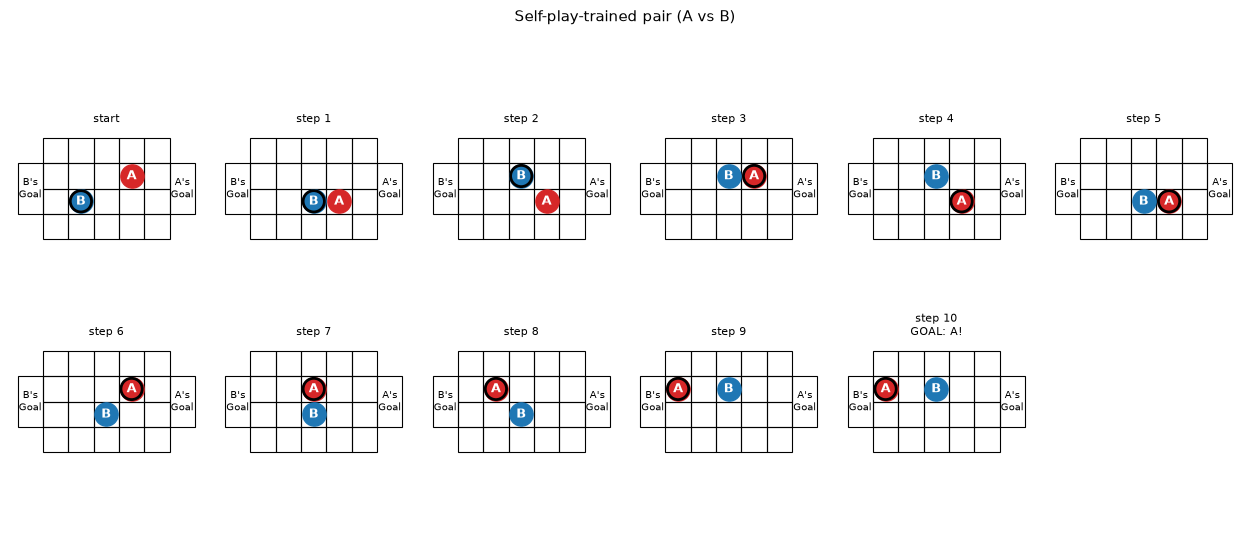

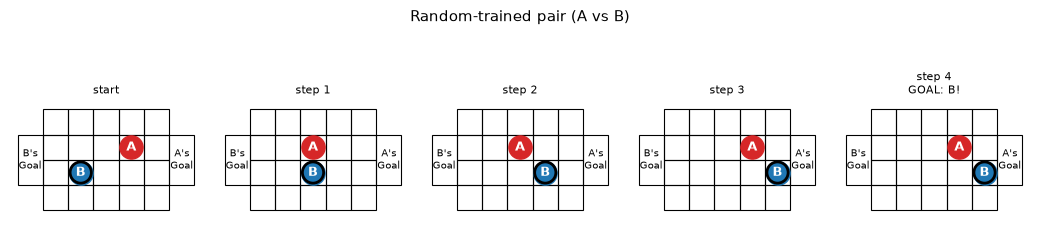

In [8]:
seed = random.Random(27)
self_trace = simulate_game_trace(a_self, b_self, seed)
plot_game_trace(self_trace, "Self-play-trained pair (A vs B)")

seed = random.Random(27)
rand_trace = simulate_game_trace(a_rand, b_rand, seed)
plot_game_trace(rand_trace, "Random-trained pair (A vs B)")